<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


In [1]:
FULLNAME = 'Mohammad Mohammadian Bisheh'
STD_ID = '401110342'

# Q3. License Plate Detection and Recognition (30 points)

## Introduction

In this assignment, we will build a two-stage license plate recognition system:

1. First stage: Detect license plates in an image (license plate detection / LPD)
2. Second stage: Recognize characters within the detected license plate (license plate recognition / LPR)

This approach is not explicitly an OCR (Optical Character Recognition), but it has some similarities with important differences. Unlike general OCR which often relies on sequence models (like RNNs or Transformers) to capture language context, license plates have a fixed format with predictable structure. This allows us to use multi-class classification or object detection models for it - first to locate plates, then to locate and classify individual characters.

## Background on YOLO (You Only Look Once)

### Evolution of Object Detection

Object detection has evolved significantly over the years:
- **Two-stage detectors** (like R-CNN family): First propose regions, then classify them
- **Single-stage detectors** (like YOLO and SSD): Predict bounding boxes and classes in a single forward pass

YOLO revolutionized object detection by framing it as a regression problem rather than a classification problem. Instead of generating region proposals and then classifying each region (a slow, two-stage process), YOLO divides the image into a grid and predicts bounding boxes and class probabilities directly in a single forward pass.

### YOLO Architecture

![YOLO Architecture](https://velog.velcdn.com/images/hunniee_j/post/cbd3888c-8b75-4325-988f-eadaded84232/image.JPG)

The basic YOLO approach:

1. **Grid Division**: Divide the image into an S×S grid
2. **Bounding Box Prediction**: Each grid cell predicts B bounding boxes, each with 5 parameters (x, y, w, h, confidence)
3. **Class Prediction**: Each grid cell also predicts class probabilities
4. **Non-Maximum Suppression**: Remove overlapping boxes with lower confidence scores

for a brief explanation of Object detection from RCNN to yolo version8 visit this [link](https://youtube.com/playlist?list=PL8VDJoEXIjppNvOzocFbRciZBrtSMi81v&si=qIh3VagQOzgWZ7Go)

the latest version of yolo is YOLO 12 and [here](https://docs.ultralytics.com/models/yolo12/) is Ultralytics documentation about it (all models of yolo family available in ultralytics has accessible documentation  [here](https://docs.ultralytics.com/models/) too.)


## Ultralytics Framework

Ultralytics is a Python library that makes it easy to train, test, and deploy YOLO models. Key features:

- **Easy to use API**: Simple Python API for training, validation, and inference
- **Pre-trained models**: Various pre-trained models of different sizes (nano to extra large)
- **Export options**: Export to various formats (ONNX, TFLite, CoreML, etc.)
- **Multi-task learning**: Support for object detection, segmentation, and pose estimation



## Assignment Tasks

In this assignment, you will:

1. Train a YOLO model for license plate detection on LPD dataset
2. Train a CNN model for license plate recognition within LPR license plates (7 digit + 1 letter classificaiton task)
3. Create an end-to-end pipeline that connects step 1 with 2
4. Evaluate the performance of your system on the test data


The dataset are available in [this](https://drive.google.com/drive/folders/1StRhbI28MaoiuXqA2rG5vGqKG5K2bMW6?usp=sharing) drive folder. let's dive into it!



In [2]:
#Necessary installations

%pip install -q ultralytics
%pip install -q matplotlib opencv-python pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.4 MB/s eta 0:00:00


In [3]:
#imports

import os
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random
import pandas as pd
import pandas as pd
from PIL import Image
import torch
from torchvision import transforms
from IPython.display import display
import pandas as pd
import torch.utils.data as data
import torch
from tqdm import tqdm
import torch.optim as optim
import torch
import torch.nn as nn
from torchvision import models
import cv2


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
!pip install --quiet gdown
!gdown --folder https://drive.google.com/drive/folders/1StRhbI28MaoiuXqA2rG5vGqKG5K2bMW6


Retrieving folder contents
Processing file 1tSza68O5AT4DK52UOiL6DZrnWENfourA LPD.zip
Processing file 14p3KgYNCyL1kE5Vyq0j9KjfJ9CPeDgJ3 LPR.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1tSza68O5AT4DK52UOiL6DZrnWENfourA
From (redirected): https://drive.google.com/uc?id=1tSza68O5AT4DK52UOiL6DZrnWENfourA&confirm=t&uuid=e565fb5b-3c82-4908-a470-7db0e5503c4e
To: /content/SUT-DL-HW2/LPD.zip
100% 3.76G/3.76G [00:49<00:00, 75.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=14p3KgYNCyL1kE5Vyq0j9KjfJ9CPeDgJ3
From (redirected): https://drive.google.com/uc?id=14p3KgYNCyL1kE5Vyq0j9KjfJ9CPeDgJ3&confirm=t&uuid=8cb82775-eb2f-4cdd-827b-a01f7e743aaa
To: /content/SUT-DL-HW2/LPR.zip
100% 256M/256M [00:04<00:00, 62.1MB/s]
Download completed


In [6]:
!unzip ./SUT-DL-HW2/LPD.zip -d LPD
!unzip ./SUT-DL-HW2/LPR.zip -d LPR

Streaming output truncated to the last 5000 lines.
  inflating: LPR/detections/5499.jpg  
  inflating: LPR/detections/55.jpg   
  inflating: LPR/detections/550.jpg  
  inflating: LPR/detections/5500.jpg  
  inflating: LPR/detections/5501.jpg  
  inflating: LPR/detections/5502.jpg  
  inflating: LPR/detections/5503.jpg  
  inflating: LPR/detections/5504.jpg  
  inflating: LPR/detections/5505.jpg  
  inflating: LPR/detections/5506.jpg  
  inflating: LPR/detections/5507.jpg  
  inflating: LPR/detections/5508.jpg  
  inflating: LPR/detections/5509.jpg  
  inflating: LPR/detections/551.jpg  
  inflating: LPR/detections/5510.jpg  
  inflating: LPR/detections/5511.jpg  
  inflating: LPR/detections/5512.jpg  
  inflating: LPR/detections/5513.jpg  
  inflating: LPR/detections/5514.jpg  
  inflating: LPR/detections/5515.jpg  
  inflating: LPR/detections/5516.jpg  
  inflating: LPR/detections/5517.jpg  
  inflating: LPR/detections/5518.jpg  
  inflating: LPR/detections/5519.jpg  
  inflating: LPR

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_PATH = '/MyDrive/Colab/DEEP/HW02/SUT-DL-HW2'
# GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'Colab/DEEP/HW02/SUT-DL-HW2'
# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
# print(os.listdir(GOOGLE_DRIVE_PATH))

# BASE_PATH = '/home/physical_security/Projects/__Amir__'

### 1. LPD - YOLO

In [8]:
LPD_RELATIVE_PATH = 'LPD'
LPD_DIR = f'./{LPD_RELATIVE_PATH}'

images_dir = os.path.join(LPD_DIR, 'images')
labels_dir = os.path.join(LPD_DIR, 'labels')
os.path.exists(images_dir)

True

In [9]:
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]

print(f"Dataset contains {len(image_files)} images and {len(label_files)} labels")


objects_count = 0
for label_file in [os.path.join(labels_dir, f) for f in label_files]:
    with open(label_file, 'r') as f:
        objects_count += len(f.readlines())

print(f"Total license plates in dataset: {objects_count}")
print(f"Average plates per image: {objects_count / max(1, len(image_files)):.2f}")

Dataset contains 6252 images and 6252 labels
Total license plates in dataset: 7257
Average plates per image: 1.16


<font color="orange">
1. What is the structure of YOLO's label files (`.txt`), and why are bounding box coordinates normalized?  

YOLO label files contain one line per object, with each line specifying:
   - `class_id`: The class of the object.
   - `x_center`, `y_center`: The normalized center coordinates of the bounding box.
   - `width`, `height`: The normalized width and height of the bounding box.

   The coordinates are normalized to be between 0 and 1, making the model robust to different image sizes and simplifying training.

<br>2. How does the YAML configuration file in YOLO define a dataset, and what role does the `nc` (number of classes) parameter play?  


The YAML file defines paths for training, validation, and optionally test data. It also specifies:
   - `nc`: The number of classes in the dataset.
   - `names`: A list of class names.

   The `nc` value helps the model understand how many categories it should classify.

<br>3. Why does YOLO use a grid system for predictions, and how does it handle multiple objects in a single grid cell?  

YOLO divides the image into a grid, with each grid cell predicting bounding boxes and class probabilities for objects within it. If multiple objects appear in one grid cell, YOLO predicts multiple boxes and uses confidence scores and non-maximum suppression to keep the most accurate box.

</font>


In [10]:
# you must create a yaml file there is just one class object detection and you must split the dataset into two parts (80%-20% for train and val)
# the executed result of cell is belong to train = val = all data for better understanding about the YOLO results.


YAML_PATH =  os.path.join(LPD_DIR, 'data.yaml')
YAML_PATH = os.path.join(LPD_DIR, 'data.yaml')

# Create a YAML configuration file where both train and val point to all data
all_images_dir = os.path.abspath(os.path.join(LPD_DIR, 'images'))

data_yaml = f"""
train: {all_images_dir}
val: {all_images_dir}
nc: 1
names: ['license_plate']
"""

with open(YAML_PATH, 'w') as f:
    f.write(data_yaml)

print(f"YAML configuration file created at: {YAML_PATH}")


YAML configuration file created at: ./LPD/data.yaml


In [11]:
VERSION = '8'
MODEL_SIZE = 'n'  # Options: n, s, m, l, x
EPOCHS = 20
IMGSZ = 640
BATCH = 16
DEVICE = 'cuda'

<font color="orange">
Compare the architectural and functional advancements in YOLO versions 8 through 12. Specifically:  

1. **YOLOv8**:  
   - **What was the motivation behind adopting an anchor-free design, and how did this impact training complexity and performance?**  
     The motivation behind adopting an anchor-free design was to simplify the model's architecture and remove the need for pre-defined anchor boxes, which often required manual tuning. This change made the model more flexible, reduced the complexity in the training process, and improved its ability to generalize to different object sizes, leading to better performance.

   - **How did the integration of CSPDarknet and PANet improve feature extraction and multi-scale detection compared to earlier versions?**  
     CSPDarknet enhanced feature extraction by using a split attention mechanism, enabling better representation of features at different levels. PANet helped improve multi-scale detection by using a path aggregation network, ensuring better information flow across different layers and improving the accuracy of detecting small and large objects.

2. **YOLOv9 (Hypothetical/Unofficial)**:  
   - **If YOLOv9 introduced dynamic label assignment, how does this differ from static assignment in YOLOv8, and what are the implications for model accuracy and convergence speed?**  
     Dynamic label assignment in YOLOv9 would allow the model to adjust label assignments during training based on object characteristics, which could improve detection accuracy by dynamically aligning with the features of the object. Unlike YOLOv8’s static assignment, this flexibility could help in improving convergence speed and overall performance on complex datasets.

   - **What role might lightweight model variants (e.g., YOLOv9n) play in edge-device deployment, and how were they optimized for resource-constrained environments?**  
     Lightweight model variants like YOLOv9n would be optimized for edge devices by reducing the model size and computational requirements. These models would focus on faster inference times with reduced memory usage, making them suitable for deployment on devices with limited resources like mobile phones and embedded systems.

3. **YOLOv10**:  
   - **How did hybrid loss functions (e.g., combining CIoU and focal loss) enhance the training process, and what challenges in object detection were they designed to address?**  
     Hybrid loss functions like CIoU and focal loss improved the training process by addressing different challenges in object detection. CIoU provided better localization accuracy, especially for tight bounding boxes, while focal loss reduced the impact of easy-to-detect examples, allowing the model to focus more on hard-to-detect objects, thus improving overall performance.

   - **What advancements in model pruning and quantization were introduced, and how did these techniques reduce model size without compromising accuracy?**  
     YOLOv10 introduced model pruning to remove redundant weights and quantization to reduce the precision of the weights, both of which significantly reduced the model size. These techniques made the model more efficient in terms of storage and computation, while maintaining accuracy by preserving the most important features of the network.

4. **YOLOv11**:  
   - **In what ways did self-calibrated convolutions improve feature extraction, and how do they compare to traditional convolutional layers in terms of computational efficiency and accuracy?**  
     Self-calibrated convolutions introduced in YOLOv11 allowed the model to adaptively adjust the convolution kernels during training, improving the extraction of relevant features. Compared to traditional convolutions, they provided better accuracy by focusing on important spatial and channel features, while also reducing computational load by dynamically adjusting the kernel weights.

   - **How did the introduction of multi-task learning (e.g., joint object detection and segmentation) expand the capabilities of YOLOv11, and what new applications does this enable?**  
     Multi-task learning in YOLOv11 allowed the model to perform both object detection and segmentation simultaneously. This expanded its capabilities to tasks like instance segmentation and semantic segmentation, which are useful in applications like autonomous driving and medical image analysis, where understanding both object boundaries and categories is critical.

5. **YOLOv12**:  
   - **What benefits does the integration of transformer-based modules bring to YOLOv12, and how does this hybrid architecture balance the strengths of CNNs and transformers?**  
     The integration of transformer-based modules in YOLOv12 enabled the model to better capture long-range dependencies and contextual relationships between objects, enhancing its ability to detect complex scenes. This hybrid architecture combines the localized feature extraction strength of CNNs with the global attention mechanism of transformers, resulting in improved accuracy and robustness in detection tasks.

   - **How does uncertainty estimation in YOLOv12 improve the reliability of predictions, particularly in safety-critical applications like autonomous driving or medical imaging?**  
     Uncertainty estimation in YOLOv12 allows the model to assess the confidence of its predictions, which is crucial for safety-critical applications. By providing uncertainty maps along with detections, it helps to avoid overconfidence in uncertain predictions, improving decision-making, especially in high-stakes environments like autonomous driving or medical diagnostics.

   - **Discuss the role of domain adaptation techniques in YOLOv12 and how they address challenges like dataset bias or environmental variability.**  
     Domain adaptation techniques in YOLOv12 help the model generalize better across different environments and datasets, particularly when training data is scarce or biased. These techniques address challenges like dataset shift and environmental variability by adjusting the model to better fit the target domain, ensuring robust performance across diverse real-world scenarios.

### Based on these advancements, which version would you recommend for this application, and why?

For this application (license plate detection and recognition), I would recommend **YOLOv8** due to its anchor-free design, which simplifies the model, and its integration of CSPDarknet and PANet for improved multi-scale detection. These features make YOLOv8 more efficient and accurate for detecting small, fixed-format objects like license plates. Additionally, its performance in real-world object detection tasks and simplicity in model architecture would be highly beneficial for this task.

</font>










In [12]:
from ultralytics import YOLO

LPD_model = YOLO('yolov8n.yaml')

In [13]:

print(f"Starting YOLO{VERSION}{MODEL_SIZE} training for {EPOCHS} epochs...")

# Check the images and labels directories
# Check the images and labels directories
!ls ./LPD/train
!ls ./LPD/val


#todo
LPD_model.train(
    data=YAML_PATH,  # Path to the updated YAML file
    imgsz=IMGSZ,     # Image size for training
    batch=BATCH,     # Batch size
    epochs=EPOCHS,   # Number of epochs
    device=DEVICE,   # Device for training (set to 'cpu' for CPU usage)
    name=f"LPD_YOLOv8_{MODEL_SIZE}_train",  # Model save name
    save=True,       # Save the model after training
    project="model", # Save under the 'model' directory
    exist_ok=True    # Allow overwriting if model folder exists
)


print("Training complete! Model saved to model/LPD folder.")

Starting YOLO8n training for 20 epochs...
ls: cannot access './LPD/train': No such file or directory
ls: cannot access './LPD/val': No such file or directory
Ultralytics 8.3.105 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=./LPD/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=model, name=LPD_YOLOv8_n_train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=

100%|██████████| 755k/755k [00:00<00:00, 14.7MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 64.6MB/s]


AMP: checks passed ✅


...

      20/20      3.33G     0.8731     0.4748      1.052         12        640: 100%|██████████| 391/391 [02:31<00:00,  2.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 196/196 [01:30<00:00,  2.15it/s]

                   all       6252       7257      0.936      0.912      0.953      0.719



20 epochs completed in 1.376 hours.
Optimizer stripped from model/LPD_YOLOv8_n_train/weights/last.pt, 6.2MB
Optimizer stripped from model/LPD_YOLOv8_n_train/weights/best.pt, 6.2MB

Validating model/LPD_YOLOv8_n_train/weights/best.pt...
Ultralytics 8.3.105 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 196/196 [01:33<00:00,  2.10it/s]


                   all       6252       7257      0.936      0.912      0.953       0.72
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to model/LPD_YOLOv8_n_train
Training complete! Model saved to model/LPD folder.


Testing model on sample images...

image 1/1 /content/LPD/images/003961.jpg: 640x384 1 license_plate, 39.6ms
Speed: 2.3ms preprocess, 39.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)


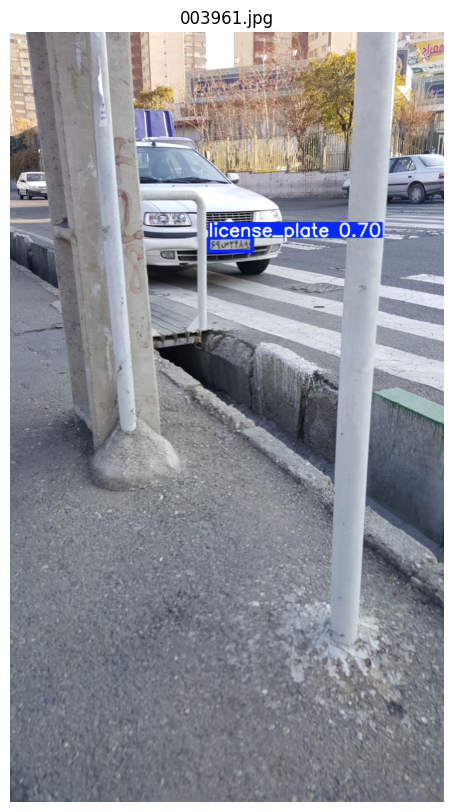


image 1/1 /content/LPD/images/005971.jpg: 384x640 2 license_plates, 51.3ms
Speed: 3.5ms preprocess, 51.3ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


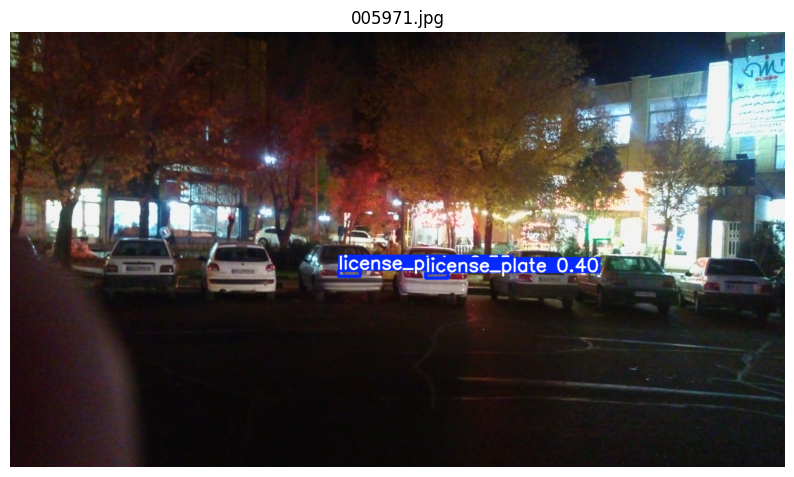


image 1/1 /content/LPD/images/006079.jpg: 480x640 1 license_plate, 58.5ms
Speed: 3.1ms preprocess, 58.5ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


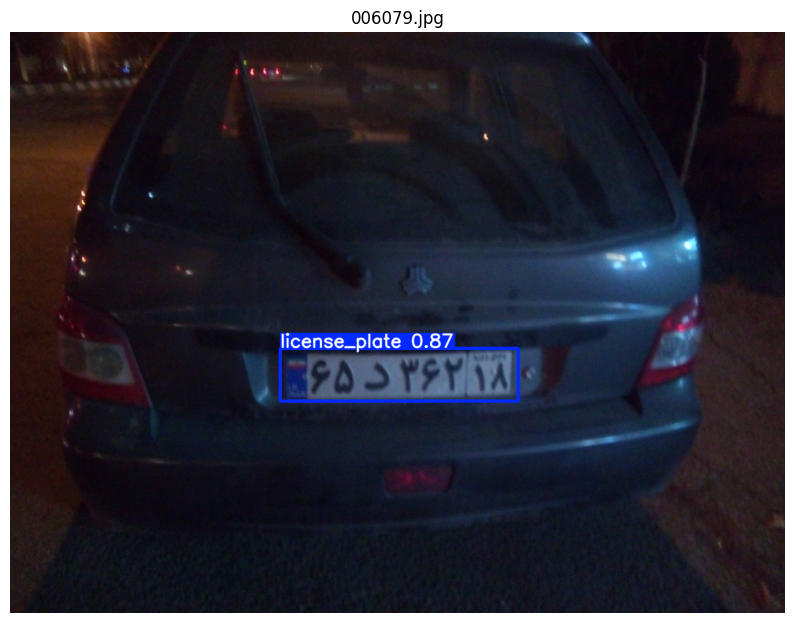


image 1/1 /content/LPD/images/005234.jpg: 640x384 1 license_plate, 9.4ms
Speed: 6.9ms preprocess, 9.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)


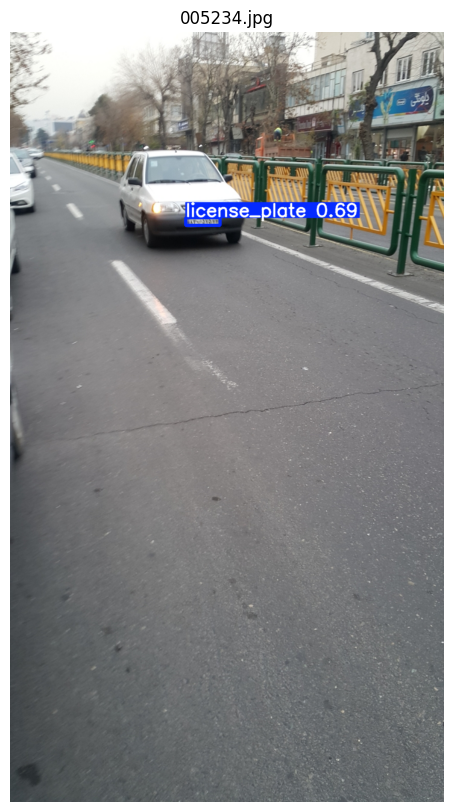


image 1/1 /content/LPD/images/004995.jpg: 640x384 1 license_plate, 9.1ms
Speed: 3.4ms preprocess, 9.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)


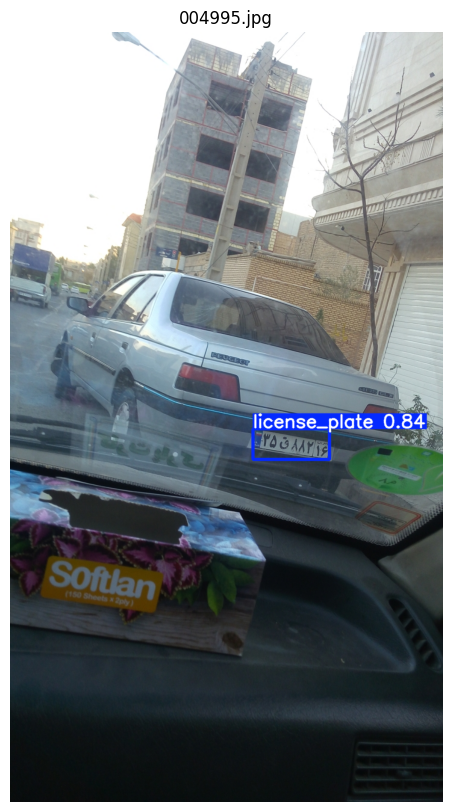

In [14]:
%matplotlib inline

print("Testing model on sample images...")
for img_file in random.sample(image_files, 5):
    img_path = os.path.join(images_dir, img_file)

    #todo
    results = LPD_model.predict(source=img_path, show=False)

    # Get the annotated image from the first result
    annotated_img = results[0].plot()

    # Display the image with detections
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title(img_file)
    plt.axis('off')
    plt.show()

### 2. LPR - CNN

In [15]:
LPR_RELATIVE_PATH = 'LPR'
LPR_DIR = f'./{LPR_RELATIVE_PATH}'

#df = pd.read_csv(f'{BASE_PATH}/{LPR_RELATIVE_PATH}/valid_samples.csv')
csv_path = os.path.join(LPR_DIR, 'valid_samples.csv')
df = pd.read_csv(csv_path)
df = df.sample(n=22000, random_state=42)

In [16]:
digit_vocabulary = "0123456789"
persian_letters = "آ ب پ ت ث ج چ ح خ د ذ ر ز ژ س ش ص ض ط ظ ع غ ف ق ک گ ل م ن و ه ی".split()


digit_to_idx = {char: idx for idx, char in enumerate(digit_vocabulary)}
letter_to_idx = {char: idx for idx, char in enumerate(persian_letters)}
idx_to_digit = {idx: char for idx, char in enumerate(digit_vocabulary)}
idx_to_letter = {idx: char for idx, char in enumerate(persian_letters)}


persian_to_english_digits = {
    '۰': '0', '۱': '1', '۲': '2', '۳': '3', '۴': '4',
    '۵': '5', '۶': '6', '۷': '7', '۸': '8', '۹': '9'
}

persian_letter_normalization = {
    "الف": "آ",
    "ا" : "آ",
    "ژ (معلولین و جانبازان)": "ژ",
    "ه‍" : "ه"
}



def translate(label):

    first_two_digits = ''.join([persian_to_english_digits.get(char, char) for char in label[:2]])
    persian_letter = label[2]
    remaining_digits = ''.join([persian_to_english_digits.get(char, char) for char in label[3:]])
    return first_two_digits + persian_letter + remaining_digits


def preprocess_sample(image_path, label , full_transform=True, log=False, dir_path = './' , relative_path= f'{LPR_RELATIVE_PATH}/detections', language='en'):

    if language == 'fa' :
      label = translate(label)

    elif language != 'en':
          raise Exception('Un-supported language!')

    path = f'{dir_path}/{relative_path}'

    train_transform = transforms.Compose([
        #todo
        transforms.Resize((64, 128)),  # example resizing
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor()
    ])

    test_transform = transforms.Compose([
        # todo
        transforms.Resize((64, 128)),  # same size for consistency
        transforms.ToTensor(),
    ])




    transform = train_transform if full_transform else test_transform
    image = Image.open(f'{path}/{image_path}').convert("RGB")
    image = transform(image)


    for key, value in persian_letter_normalization.items():
        label = label.replace(key, value)



    if log:
      print(label)

      for i , c in enumerate(label):
        if c in persian_letters:
          c = '*'
        print(f"{i}:{c}", end=' | ')

      print()


    digits = [digit_to_idx[char] for char in label if char.isdigit()]
    letter = letter_to_idx[label[2]]

    return image, digits, letter

In [17]:
class PLPRDataset(data.Dataset):
    def __init__(self, df , split='train',dir_path='./',relative_path = f'{LPR_RELATIVE_PATH}/detections', language='en'):
        self.df = df
        self.full_transform = True if split == 'train' else False
        self.dir_path = dir_path
        self.relative_path = relative_path
        self.language = language

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # todo
        image_path, label = self.df.iloc[idx]
        image, digits, letter = preprocess_sample(
            image_path=image_path,
            label=label,
            full_transform=self.full_transform,
            dir_path=self.dir_path,
            relative_path=self.relative_path,
            language=self.language
        )

        digits_tensor = torch.tensor(digits, dtype=torch.long)
        letter_tensor = torch.tensor(letter, dtype=torch.long)
        return image, digits_tensor, letter_tensor


In [18]:
import timm
class FCNPLPRModel(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0"):
        super(FCNPLPRModel, self).__init__()

        # todo
        self.backbone = timm.create_model(backbone_name, pretrained=True, features_only=True)
        feature_dim = self.backbone.feature_info[-1]['num_chs']

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()

        self.digit_head = nn.Linear(feature_dim, 7 * 10)  # 7 digits, 10 classes
        self.letter_head = nn.Linear(feature_dim, len(persian_letters))  # 32 letters

    def forward(self, x):
        # todo
        # digit_outputs , letter_output = None
        #digit_outputs  -> [batch_size, 7, 10]
        #letter_output -> [batch_size, num_persian_letters]
        features = self.backbone(x)[-1]  # last feature map
        pooled = self.global_pool(features)
        flat = self.flatten(pooled)

        digit_logits = self.digit_head(flat).view(-1, 7, 10)
        letter_logits = self.letter_head(flat)

        digit_outputs, letter_output = digit_logits, letter_logits
        return digit_outputs, letter_output

        return digit_outputs, letter_output

In [19]:
learning_rate = 4e-4
batch_size = 32

In [20]:
dataset = PLPRDataset(df)
dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        # persistent_workers=True
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [21]:
LPR_model = FCNPLPRModel().to(device)
digit_criterion = nn.CrossEntropyLoss()
letter_criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [22]:
optimizer = optim.AdamW(LPR_model.parameters(), lr=learning_rate)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    threshold=0.05,
    threshold_mode='rel',
    verbose=True
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [23]:
def decode_predictions(digit_outputs, letter_output):
    digit_predictions = torch.argmax(digit_outputs, dim=2)  # [batch_size, 7]
    batch_size = digit_predictions.size(0)

    digits = []
    for b in range(batch_size):  # Iterate over batch
        sample_digits = []
        for i in range(7):  # Iterate over 7 digits
            try:
                sample_digits.append(idx_to_digit[digit_predictions[b][i].item()])
            except KeyError as e:
                print(f"KeyError: {e} (digit_predictions[{b}][{i}] = {digit_predictions[b][i].item()})")
                sample_digits.append("?")  # Use a placeholder for invalid indices
        digits.append(sample_digits)

    letter_prediction = torch.argmax(letter_output, dim=1)  # [batch_size]
    letters = []
    for b in range(batch_size):
        try:
            letters.append(idx_to_letter[letter_prediction[b].item()])
        except KeyError as e:
            print(f"KeyError: {e} (letter_prediction[{b}] = {letter_prediction[b].item()})")
            letters.append("?")  # Use a placeholder for invalid indices

    labels = []
    for b in range(batch_size):
        label = "".join(digits[b][:2]) + letters[b] + "".join(digits[b][2:])
        labels.append(label)

    return labels



def evaluate_misclassification(gt, pred):
    assert len(gt) == len(pred), "GT and Pred must have the same length."

    # Collect misclassified characters
    misclassified = []
    char_error_count = 0

    for i, (gt_char, pred_char) in enumerate(zip(gt, pred)):
        if gt_char != pred_char:
            misclassified.append(f"{gt_char} with {pred_char} at pos {i}")
            char_error_count += 1

    # Format the output
    misclassified_str = " , ".join(misclassified) if misclassified else "None"
    result = (f"GT: {gt} | Pred: {pred} | "
              f"Misclassified: {misclassified_str} | "
              f"Char error count: {char_error_count}")

    return result , char_error_count





def calculate_accuracy(model, df, device, dir_path='./', relative_path=f'{LPR_RELATIVE_PATH}/detections', language='en', log=False , cer = False):
    model.eval()
    FP= []
    CE = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df)):
            image_path = row["image_path"]
            label = row["label"]
            try:
                image, true_digits, true_letter = preprocess_sample(image_path, label, full_transform=False, dir_path=dir_path, relative_path=relative_path, language=language)

            except Exception as e:
                print(f"Error processing {image_path}: {e}")
                continue
            true_label = "".join([digit_vocabulary[d] for d in true_digits[:2]]) \
                         + persian_letters[true_letter] \
                         + "".join([digit_vocabulary[d] for d in true_digits[2:]])
            image = image.unsqueeze(0).to(device)
            digit_outputs, letter_output = model(image)

            predicted_labels = decode_predictions(digit_outputs, letter_output)

            if predicted_labels[0] == true_label:
                correct += 1
            elif log:
                report , char_error_count = evaluate_misclassification(true_label,predicted_labels[0])
                CE += char_error_count
                FP.append(report)
            total += 1


    accuracy = correct / total * 100

    if cer:
        print(f'CER: {100* CE/(8*df.shape[0]): .4f}%')

    if log:
         for false_positive in FP:
            print(false_positive)



    return accuracy

In [24]:
full_df = pd.read_csv('./LPR/valid_samples.csv')
test_df = full_df.loc[~full_df.index.isin(df.index)]


In [25]:
best_accuracy = 85.0
optimal_weights = None
num_epochs = 10


for epoch in range(num_epochs):
    LPR_model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, digit_targets, letter_targets in progress_bar:
        images = images.to(device)
        digit_targets = digit_targets.to(device)
        letter_targets = letter_targets.to(device)

        # Forward pass
        digit_outputs, letter_output = LPR_model(images)

        digit_loss = 0
        for i in range(7):
            digit_loss += digit_criterion(digit_outputs[:, i, :], digit_targets[:, i])
        letter_loss = letter_criterion(letter_output, letter_targets)
        loss = digit_loss + letter_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

    LPR_model.eval()
    accuracy = calculate_accuracy(
        LPR_model,
        test_df,
        device,
        relative_path= f'{LPR_RELATIVE_PATH}/detections',
        language='en'
    )
    print(f"Accuracy after Epoch {epoch+1}: {accuracy:.2f}%")

    scheduler.step(accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        optimal_weights = LPR_model.state_dict()  # Save the current model weights
        print(f"New best accuracy: {best_accuracy:.2f}%. Saving model weights.")
        torch.save(LPR_model.state_dict(), f'./model/PLPR-CNN.pth')

if optimal_weights is not None:
    LPR_model.load_state_dict(optimal_weights)
    print("Loaded optimal weights into the model.")

Epoch 1/10:   0%|          | 0/688 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/10, Average Loss: 9.5352


100%|██████████| 2561/2561 [00:32<00:00, 79.36it/s]


Accuracy after Epoch 1: 62.51%


Epoch 2/10, Average Loss: 1.6542


...

100%|██████████| 2561/2561 [00:30<00:00, 83.17it/s]


Accuracy after Epoch 9: 89.85%
New best accuracy: 89.85%. Saving model weights.


Epoch 10/10, Average Loss: 0.1160


100%|██████████| 2561/2561 [00:31<00:00, 80.29it/s]

Accuracy after Epoch 10: 89.42%
Loaded optimal weights into the model.


In [26]:

# Calculate accuracy
accuracy = calculate_accuracy(LPR_model, test_df, device, cer=True, log=True)
print(f"Accuracy: {accuracy:.2f}%")

100%|██████████| 2561/2561 [00:31<00:00, 81.65it/s]

CER:  1.9084%
GT: 51ژ66416 | Pred: 51ع66416 | Misclassified: ژ with ع at pos 2 | Char error count: 1
GT: 57ژ46711 | Pred: 57ط46711 | Misclassified: ژ with ط at pos 2 | Char error count: 1
GT: 81ع27744 | Pred: 81ع37744 | Misclassified: 2 with 3 at pos 3 | Char error count: 1
GT: 52ع35813 | Pred: 52ع25812 | Misclassified: 3 with 2 at pos 3 , 3 with 2 at pos 7 | Char error count: 2
GT: 65ع57544 | Pred: 25ع57544 | Misclassified: 6 with 2 at pos 0 | Char error count: 1
GT: 81ت74133 | Pred: 89ت74133 | Misclassified: 1 with 9 at pos 1 | Char error count: 1
GT: 45ت87733 | Pred: 45ت87722 | Misclassified: 3 with 2 at pos 6 , 3 with 2 at pos 7 | Char error count: 2
GT: 93ت57132 | Pred: 93ت57133 | Misclassified: 2 with 3 at pos 7 | Char error count: 1
GT: 21ت13611 | Pred: 21ت13633 | Misclassified: 1 with 3 at pos 6 , 1 with 3 at pos 7 | Char error count: 2
GT: 91ی36388 | Pred: 61ی43388 | Misclassified: 9 with 6 at pos 0 , 3 with 4 at pos 3 , 6 with 3 at pos 4 | Char error count: 3
GT: 93ی57410 | P

### 3. E2E LPDR

load the models from part 2 and 3, build a class named E2E_LPDR and plot report the metrics (accuracy and cer) for the test dataset (20% of LPD that has Splitted in section 1 ). you must also plot some samples with predicted bounding box and label too.


note that each picture might have multiple plates but in this test data for simplicity all samples just have a single plate exists in it.
plot some samples from your pipeline (predicted bb from an image + predicted label of it)


In [27]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2
from sklearn.metrics import accuracy_score

class E2E_LPDR:
    def __init__(self, LPD_model, LPR_model, device='cpu'):
        self.device = device

        # Accept YOLO model directly
        self.detector = LPD_model.to(device)
        self.detector.eval()

        self.LPR_model = LPR_model.to(device)
        self.LPR_model.eval()

    def calculate_cer(self, true_label, predicted_label):
        """Calculate Character Error Rate (CER)."""
        true_chars = list(true_label)
        predicted_chars = list(predicted_label)

        # Levenshtein-like character error approximation
        distance = 0
        for i in range(min(len(true_chars), len(predicted_chars))):
            if true_chars[i] != predicted_chars[i]:
                distance += 1

        distance += abs(len(true_chars) - len(predicted_chars))
        cer = distance / max(len(true_chars), 1)
        return cer

    def predict(self, image_path):
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Detect license plates using YOLOv8 model
        results = self.detector(image_rgb)
        result = results[0]

        boxes = result.boxes.xywh.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()

        predicted_bbs = []
        predicted_labels = []

        for i in range(len(boxes)):
            x, y, w, h = boxes[i]
            conf = confidences[i]
            if conf > 0.5:
                # Crop the plate region
                crop = image[int(y - h/2):int(y + h/2), int(x - w/2):int(x + w/2)]
                if crop.size == 0:
                    continue
                crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

                # Preprocess for LPR model
                crop_tensor = preprocess_sample(crop, label="0000000", full_transform=False)
                with torch.no_grad():
                    digit_logits, letter_logits = self.LPR_model(crop_tensor.unsqueeze(0).to(self.device))
                    predicted_digits = ''.join([idx_to_digit[d.item()] for d in digit_logits.argmax(dim=2)[0]])
                    predicted_letter = idx_to_letter[letter_logits.argmax(dim=1)[0].item()]
                    predicted_label = predicted_digits[:2] + predicted_letter + predicted_digits[2:]

                predicted_bbs.append((x, y, w, h))
                predicted_labels.append(predicted_label)

        return predicted_bbs, predicted_labels, image_rgb

    def evaluate(self, test_dataset):
        """Evaluate the model on the test dataset and report accuracy and CER."""
        all_true_labels = []
        all_pred_labels = []
        all_cers = []

        for idx, (image_path, true_label) in enumerate(test_dataset):
            try:
                predicted_bbs, predicted_labels, image_rgb = self.predict(image_path)

                if not predicted_labels:
                    continue  # Skip if no prediction made

                all_true_labels.append(true_label)
                all_pred_labels.append(predicted_labels[0])

                cer = self.calculate_cer(true_label, predicted_labels[0])
                all_cers.append(cer)

            except Exception as e:
                print(f"[Warning] Skipping {image_path}: {e}")

        accuracy = accuracy_score(all_true_labels, all_pred_labels)
        mean_cer = np.mean(all_cers)

        print(f"Accuracy: {accuracy * 100:.2f}%")
        print(f"Mean CER: {mean_cer:.4f}")
        return accuracy, mean_cer

    def plot_sample_predictions(self, test_dataset, num_samples=5):
        """Plot some test samples with predicted bounding boxes and labels."""
        samples = random.sample(test_dataset, num_samples)

        for image_path, true_label in samples:
            try:
                predicted_bbs, predicted_labels, image_rgb = self.predict(image_path)

                plt.figure(figsize=(10, 10))
                plt.imshow(image_rgb)
                ax = plt.gca()

                for i, (x, y, w, h) in enumerate(predicted_bbs):
                    ax.add_patch(plt.Rectangle((x - w/2, y - h/2), w, h, linewidth=2, edgecolor='r', facecolor='none'))
                    ax.text(x, y, predicted_labels[i], color='r', fontsize=12)

                plt.title(f"True Label: {true_label}")
                plt.axis('off')
                plt.show()
            except Exception as e:
                print(f"[Warning] Failed to plot {image_path}: {e}")


In [28]:
df = pd.read_csv(os.path.join(LPD_DIR, "plate_labels.csv"))
print(df.columns)
print(df.head())


Index(['index', 'image_path', 'label'], dtype='object')
   index  image_path     label
0      1  000001.jpg  48و15116
1      2  000002.jpg  78س92616
2      3  000003.jpg  73ب31536
3      4  000004.jpg  35و33669
4      5  000005.jpg  39ص29449


Test dataset created, sample entries:
[('./LPD/images/001704.jpg', '12ق98416'), ('./LPD/images/005449.jpg', '95م59277'), ('./LPD/images/005059.jpg', '14م32316'), ('./LPD/images/001150.jpg', '36ط11338 53ب49510'), ('./LPD/images/000433.jpg', '84ل69311')]



0: 640x480 (no detections), 41.5ms
Speed: 2.8ms preprocess, 41.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 (no detections), 6.6ms
Speed: 2.8ms preprocess, 6.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 (no detections), 14.6ms
Speed: 2.2ms preprocess, 14.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 480x640 (no detections), 14.7ms
Speed: 2.4ms preprocess, 14.7ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 640x384 (no detections), 14.6ms
Speed: 2.0ms preprocess, 14.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x480 (no detections), 11.0ms
Speed: 3.9ms preprocess, 11.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)

0: 160x640 (no detections), 38.9ms
Speed: 1.6ms preprocess, 38.9ms inference, 0.6ms postprocess per image at shape (1, 3, 160, 640)

0: 480x640 (no detections), 7.7ms
Speed: 2.6ms preprocess, 7.7ms infer

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


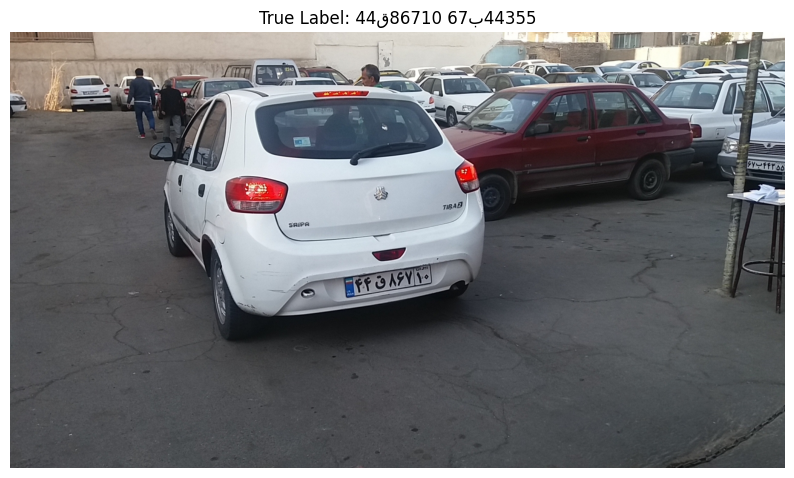


0: 640x480 (no detections), 11.1ms
Speed: 3.0ms preprocess, 11.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


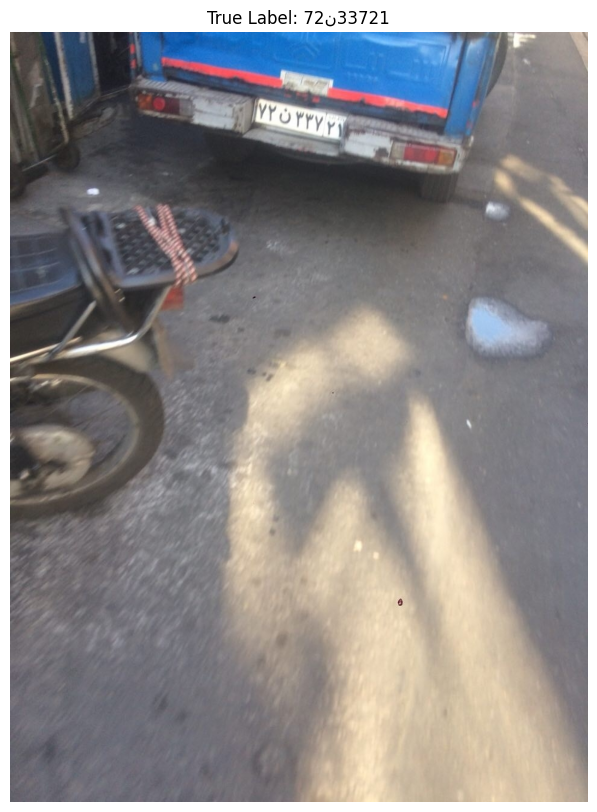


0: 640x480 (no detections), 8.5ms
Speed: 4.3ms preprocess, 8.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)


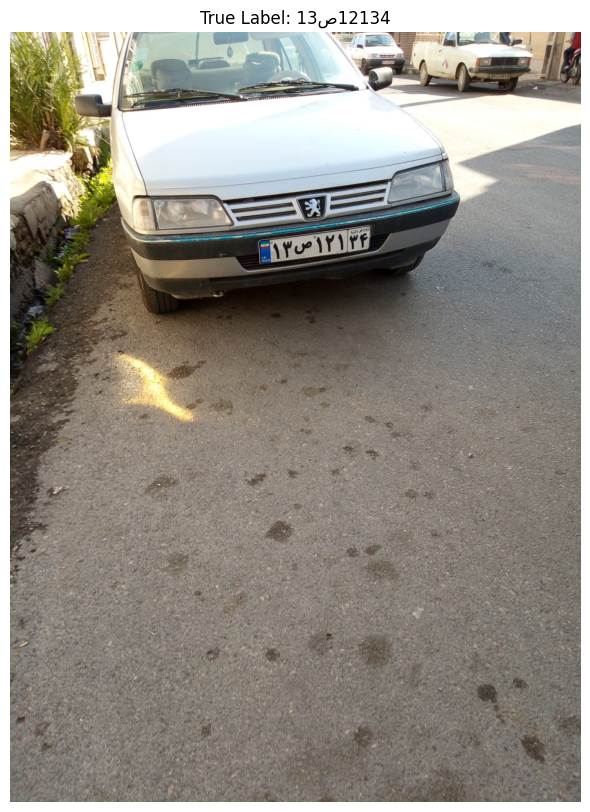


0: 640x480 (no detections), 10.3ms
Speed: 2.9ms preprocess, 10.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


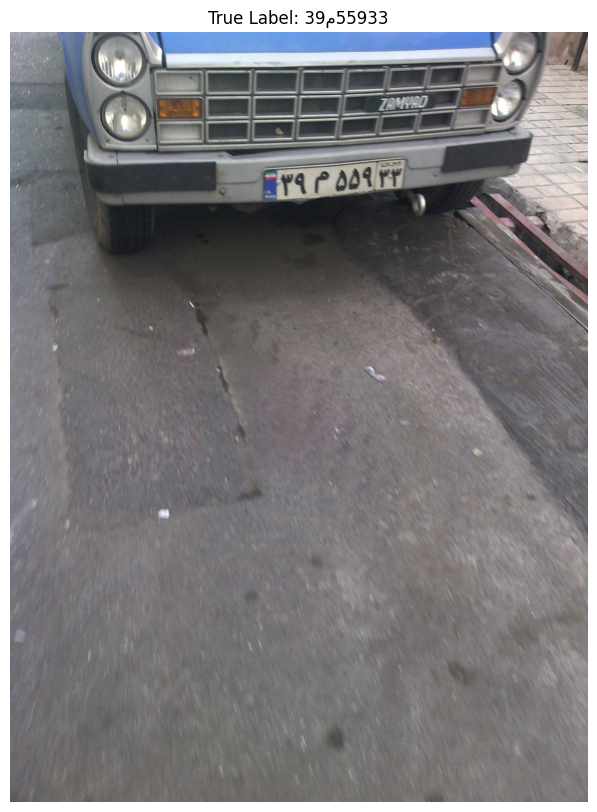


0: 640x384 (no detections), 13.5ms
Speed: 2.4ms preprocess, 13.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)


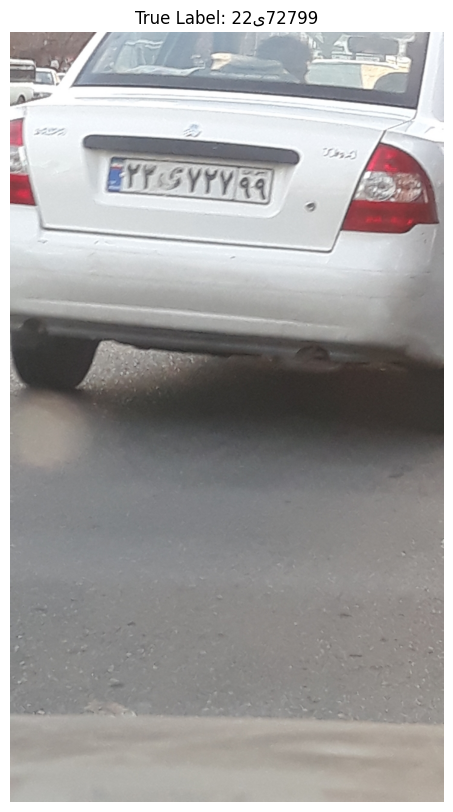

In [29]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

# Assuming BASE_PATH and LPD_DIR are already defined
# Example:
# BASE_PATH = '/content'
# LPD_RELATIVE_PATH = 'LPD'
# LPD_DIR = os.path.join(BASE_PATH, LPD_RELATIVE_PATH)

# ---------------------------
# 1. Create the test dataset from LPD/plate_labels.csv
# ---------------------------
csv_path = os.path.join(LPD_DIR, "plate_labels.csv")
df = pd.read_csv(csv_path)

# Split the data: use 20% of the data for testing
_, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Assuming the CSV contains columns "filename" and "label"
test_dataset = [
    (os.path.join(LPD_DIR, "images", row["image_path"]), row["label"])
    for _, row in test_df.iterrows()
]

print("Test dataset created, sample entries:")
print(test_dataset[:5])


# ---------------------------
# 2. Load the models
# ---------------------------
# Load YOLOv8 model for License Plate Detection (LPD)
LPD_model = YOLO('yolov8n.yaml')  # Make sure this YAML file/model is accessible

# Load the LPR (License Plate Recognition) model (custom FCNPLPRModel)
# Ensure FCNPLPRModel is defined and imported from your modules
LPR_model = FCNPLPRModel().to(device)  # device should be 'cpu' or 'cuda' as available

# ---------------------------
# 3. Initialize the End-to-End License Plate Detection and Recognition (E2E LPDR) Pipeline
# ---------------------------
# Ensure that the E2E_LPDR class is defined and imported from your code
e2e_lpdr = E2E_LPDR(LPD_model, LPR_model, device=device)

# ---------------------------
# 4. Evaluate the E2E pipeline on the test dataset and report metrics
# ---------------------------
accuracy, mean_cer = e2e_lpdr.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Mean CER: {mean_cer:.4f}")

# ---------------------------
# 5. Plot sample predictions from the test dataset
# ---------------------------
e2e_lpdr.plot_sample_predictions(test_dataset, num_samples=5)
